In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
model_family_map = {
    "Qwen2.5-7B": "Qwen2.5",
    "Qwen2.5-7B-Instruct": "Qwen2.5",
    "Yi-1.5-9B": "Yi-1.5",
    "Yi-1.5-9B-Chat": "Yi-1.5",
    "internlm2_5-7b": "InternLM2.5",
    "internlm3-8b-instruct": "InternLM2.5",
    "Baichuan2-7B-Base": "Baichuan2",
    "Baichuan2-7B-Chat": "Baichuan2",
    "Meta-Llama-3-8B": "Llama3",
    "Meta-Llama-3-8B-Instruct": "Llama3",
    "Mistral-7B-v0.3": "Mistral",
    "Mistral-7B-Instruct-v0.3": "Mistral",
    "gemma-2-9b": "Gemma2",
    "gemma-2-9b-it": "Gemma2",
    "OLMo-2-1124-7B": "OLMo2",
    "OLMo-2-1124-7B-Instruct": "OLMo2",
    "DeepSeek-R1-Distill-Llama-8B": "DeepSeek-R1",
    "DeepSeek-R1-Distill-Qwen-7B": "DeepSeek-R1",
}

## Floresp

In [5]:
floresp = pd.read_csv("floresp_nll_output_v2.csv")

In [6]:
floresp.head()

,index,n_toks,nll_sum,ppl,lang_code,lang_name,lang_category,model_name,n_chars,model_name_abrev,model_path_hf,model_source,instruction_tuned,system_prompt,ip
0,0,71,196.396179,16.537983,yue_Hant,Yue (Cantonese),Chinese Han Dialects (Other),Qwen2.5-7B,78,Qwen2.5,Qwen/Qwen2.5-7B,China,0,NaN,0.685952
1,1,55,176.154510,26.104834,yue_Hant,Yue (Cantonese),Chinese Han Dialects (Other),Qwen2.5-7B,70,Qwen2.5,Qwen/Qwen2.5-7B,China,0,NaN,0.641538
2,2,50,163.736237,28.263063,yue_Hant,Yue (Cantonese),Chinese Han Dialects (Other),Qwen2.5-7B,61,Qwen2.5,Qwen/Qwen2.5-7B,China,0,NaN,0.661234
3,3,19,94.257431,188.015442,yue_Hant,Yue (Cantonese),Chinese Han Dialects (Other),Qwen2.5-7B,21,Qwen2.5,Qwen/Qwen2.5-7B,China,0,NaN,0.801731
4,4,16,80.061386,207.976730,yue_Hant,Yue (Cantonese),Chinese Han Dialects (Other),Qwen2.5-7B,22,Qwen2.5,Qwen/Qwen2.5-7B,China,0,NaN,0.703016


In [7]:
floresp = floresp[(floresp['model_source'].isin(["China", "Western"])) & (floresp['model_name_abrev'] != "DeepSeek-R1-Llama")].copy()

In [8]:
df = floresp.groupby(["lang_code", "lang_name", "lang_category", "model_name", "model_name_abrev", "model_source", "instruction_tuned"])['ip'].agg(["size", "mean"]).reset_index()
df = df.rename({"mean": "mean_ip"}, axis=1)
df['model_family'] = df['model_name'].apply(lambda m: model_family_map[m])

In [9]:
df = df[df['model_family'] != "DeepSeek-R1"]
df = df[df['lang_name'] != "English"]
df = pd.pivot(df,index=['lang_name', 'model_family', 'model_source'], columns='instruction_tuned', values='mean_ip').reset_index()
df['change'] = df[1] - df[0]

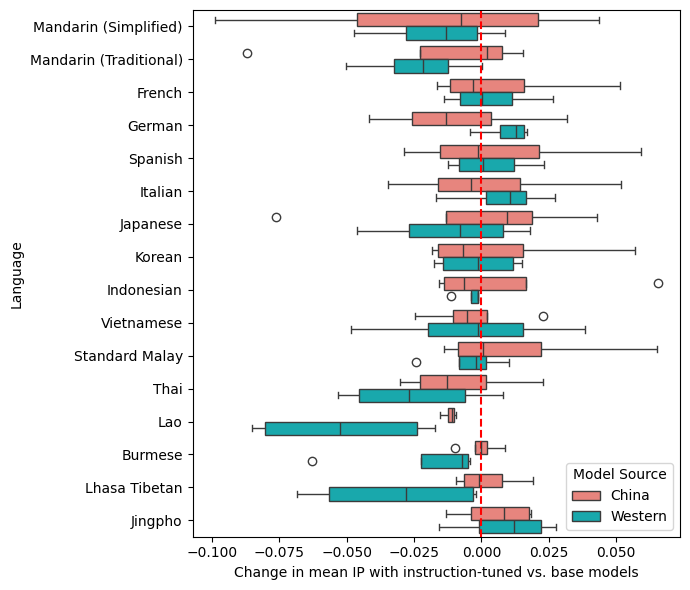

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
g = sns.boxplot(df, x='change', y='lang_name', hue='model_source', palette={"China": "#f8766d", "Western": "#00bfc5"},
order = ["Mandarin (Simplified)", "Mandarin (Traditional)", "French", "German", "Spanish", "Italian",  "Japanese", "Korean", "Indonesian", "Vietnamese", 
"Standard Malay", "Thai", "Lao", "Burmese", "Lhasa Tibetan", "Jingpho"])

plt.axvline(x=0, ls='--', c='red')
plt.xlabel("Change in mean IP with instruction-tuned vs. base models")
plt.ylabel("Language")
plt.legend(title='Model Source')
plt.tight_layout()
plt.savefig("./figures/floresp-instruction-tuned-change-by-language-breakdown-model-source.pdf")

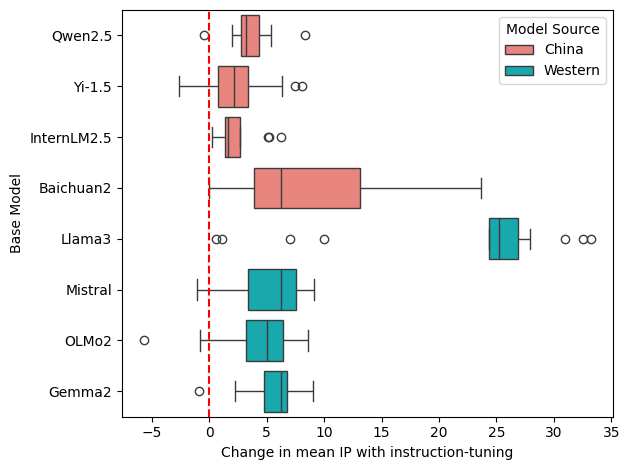

In [30]:
g = sns.boxplot(df, y='model_family', x='change', palette={"China": "#f8766d", "Western": "#00bfc5"},
order = ["Qwen2.5", "Yi-1.5", "InternLM2.5", "Baichuan2", "Llama3", "Mistral", "OLMo2", "Gemma2"], hue='model_source')
plt.axvline(x=0, ls='--', c='red')
plt.xlabel("Change in mean IP with instruction-tuning")
plt.ylabel("Base Model")
plt.legend(title="Model Source")
plt.tight_layout()
plt.savefig("./figures/floresp-instruction-tuned-change-by-model.pdf")

## Bele

In [14]:
bele = pd.read_csv("bele_output.csv")

bele['model_family'] = bele['model_name'].apply(lambda m: model_family_map[m])
bele['accuracy'] = 100 * bele['accuracy']

In [15]:
bele = bele[bele['chat_template'] == 0].copy()
bele.head()

,model_name,lang_category,lang_code,lang_name,accuracy,answer_stats,chat_template,model_name_abrev,model_path_hf,model_source,instruction_tuned,system_prompt,model_family
0,Qwen2.5-7B,Chinese Minorities,bod_Tibt,Lhasa Tibetan,28.222222,"Counter({'A': 335, 'C': 247, 'B': 210, 'D': 108})",0,Qwen2.5,Qwen/Qwen2.5-7B,China,0,NaN,Qwen2.5
1,Yi-1.5-9B,Chinese Minorities,bod_Tibt,Lhasa Tibetan,26.888889,"Counter({'C': 328, 'D': 289, 'B': 205, 'A': 78})",0,Yi-1.5,01-ai/Yi-1.5-9B,China,0,NaN,Yi-1.5
3,DeepSeek-R1-Distill-Llama-8B,Chinese Minorities,bod_Tibt,Lhasa Tibetan,28.555556,"Counter({'B': 358, 'C': 268, 'D': 182, 'A': 91...",0,DeepSeek-R1-Llama,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,China,1,NaN,DeepSeek-R1
5,DeepSeek-R1-Distill-Qwen-7B,Chinese Minorities,bod_Tibt,Lhasa Tibetan,21.111111,"Counter({'A': 374, 'C': 168, 'D': 143, 'B': 12...",0,DeepSeek-R1-Qwen,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,China,1,NaN,DeepSeek-R1
6,internlm2_5-7b,Chinese Minorities,bod_Tibt,Lhasa Tibetan,26.888889,"Counter({'D': 619, 'A': 159, 'B': 87, 'C': 35})",0,InternLM2.5,internlm/internlm2_5-7b,China,0,NaN,InternLM2.5


In [16]:
bele = bele[(bele['model_source'].isin(["China", "Western"])) & (bele['model_name_abrev'] != "DeepSeek-R1-Llama")].copy()
print(bele.shape)
bele.head()

(289, 13)


,model_name,lang_category,lang_code,lang_name,accuracy,answer_stats,chat_template,model_name_abrev,model_path_hf,model_source,instruction_tuned,system_prompt,model_family
0,Qwen2.5-7B,Chinese Minorities,bod_Tibt,Lhasa Tibetan,28.222222,"Counter({'A': 335, 'C': 247, 'B': 210, 'D': 108})",0,Qwen2.5,Qwen/Qwen2.5-7B,China,0,NaN,Qwen2.5
1,Yi-1.5-9B,Chinese Minorities,bod_Tibt,Lhasa Tibetan,26.888889,"Counter({'C': 328, 'D': 289, 'B': 205, 'A': 78})",0,Yi-1.5,01-ai/Yi-1.5-9B,China,0,NaN,Yi-1.5
5,DeepSeek-R1-Distill-Qwen-7B,Chinese Minorities,bod_Tibt,Lhasa Tibetan,21.111111,"Counter({'A': 374, 'C': 168, 'D': 143, 'B': 12...",0,DeepSeek-R1-Qwen,deepseek-ai/DeepSeek-R1-Distill-Qwen-7B,China,1,NaN,DeepSeek-R1
6,internlm2_5-7b,Chinese Minorities,bod_Tibt,Lhasa Tibetan,26.888889,"Counter({'D': 619, 'A': 159, 'B': 87, 'C': 35})",0,InternLM2.5,internlm/internlm2_5-7b,China,0,NaN,InternLM2.5
7,Baichuan2-7B-Base,Chinese Minorities,bod_Tibt,Lhasa Tibetan,30.111111,"Counter({'D': 367, 'C': 279, 'A': 136, 'B': 118})",0,Baichuan2,baichuan-inc/Baichuan2-7B-Base,China,0,NaN,Baichuan2


In [17]:
from scipy import stats

df = bele[bele['instruction_tuned'] == 1]
print(df['model_name_abrev'].unique())
df = pd.pivot(df.groupby(['lang_code', 'model_source'])['accuracy'].mean().reset_index(), index='lang_code', columns='model_source', values='accuracy')
print(stats.pearsonr(df['China'], df['Western']))


df = bele[bele['instruction_tuned'] == 0]
print(df['model_name_abrev'].unique())
df = pd.pivot(df.groupby(['lang_code', 'model_source'])['accuracy'].mean().reset_index(), index='lang_code', columns='model_source', values='accuracy')
print(stats.pearsonr(df['China'], df['Western']))



['DeepSeek-R1-Qwen' 'Qwen2.5-Instruct' 'Yi-1.5-Chat' 'InternLM3-Instruct'
 'Baichuan2-Chat' 'Llama3-Instruct' 'Mistral-Instruct' 'Gemma2-Instruct'
 'Olmo2-Instruct']
PearsonRResult(statistic=0.9906843255426833, pvalue=2.09831143096001e-14)
['Qwen2.5' 'Yi-1.5' 'InternLM2.5' 'Baichuan2' 'Llama3' 'Mistral' 'Gemma2'
 'Olmo2']
PearsonRResult(statistic=0.9812982571861714, pvalue=3.802960557254655e-12)


In [18]:
from scipy import stats

df = bele.groupby(['lang_code', 'model_source', 'instruction_tuned'])['accuracy'].mean().reset_index()
df_base = pd.pivot(df[df['instruction_tuned']==0], index='lang_code', columns='model_source', values='accuracy')
print(stats.pearsonr(df_base['China'], df_base['Western']))

df_chat = pd.pivot(df[df['instruction_tuned']==1], index='lang_code', columns='model_source', values='accuracy')
print(stats.pearsonr(df_chat['China'], df_chat['Western']))


PearsonRResult(statistic=0.9812982571861714, pvalue=3.802960557254655e-12)
PearsonRResult(statistic=0.9906843255426833, pvalue=2.09831143096001e-14)


### instruction tuned vs no instruction tuned

In [19]:
bele['model_source'].unique()

array(['China', 'Western'], dtype=object)

In [20]:
df = (bele[~(bele['model_name'].str.contains('DeepSeek')) & (bele['chat_template'] == 0)]).groupby(['lang_code', 'lang_name', 'model_family', 'model_source', 'instruction_tuned'])['accuracy'].mean().reset_index()
df

,lang_code,lang_name,model_family,model_source,instruction_tuned,accuracy
0,bod_Tibt,Lhasa Tibetan,Baichuan2,China,0,30.111111
1,bod_Tibt,Lhasa Tibetan,Baichuan2,China,1,30.555556
2,bod_Tibt,Lhasa Tibetan,Gemma2,Western,0,36.000000
3,bod_Tibt,Lhasa Tibetan,Gemma2,Western,1,38.222222
4,bod_Tibt,Lhasa Tibetan,InternLM2.5,China,0,26.888889
...,...,...,...,...,...,...
267,zsm_Latn,Standard Malay,OLMo2,Western,1,64.111111
268,zsm_Latn,Standard Malay,Qwen2.5,China,0,77.444444
269,zsm_Latn,Standard Malay,Qwen2.5,China,1,80.444444
270,zsm_Latn,Standard Malay,Yi-1.5,China,0,69.333333


In [21]:
df = pd.pivot(df,index=['lang_name', 'model_family', 'model_source'], columns='instruction_tuned', values='accuracy').reset_index()
df['change'] = df[1] - df[0]

In [23]:
df['model_source'] = df['model_source'].apply(lambda m: "Western" if m == "US/Europe" else m)

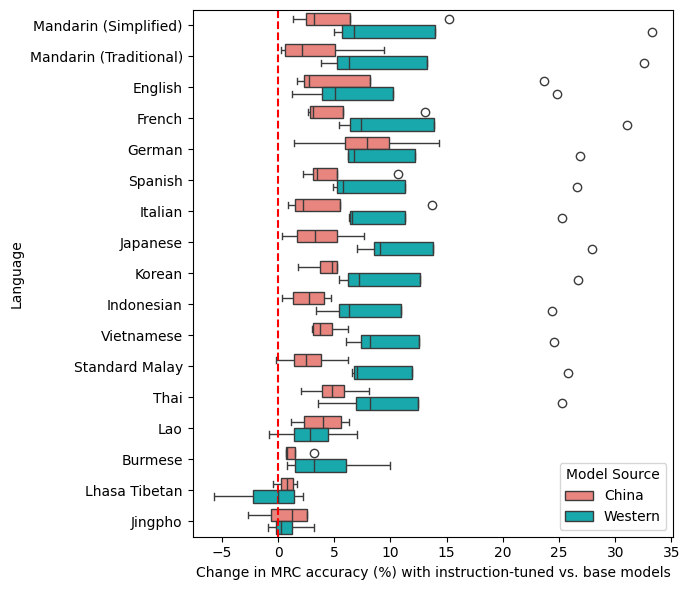

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
g = sns.boxplot(df, x='change', y='lang_name', hue='model_source', palette={"China": "#f8766d", "Western": "#00bfc5"},
order = ["Mandarin (Simplified)", "Mandarin (Traditional)", "English", "French", "German", "Spanish", "Italian",  "Japanese", "Korean", "Indonesian", "Vietnamese", 
"Standard Malay", "Thai", "Lao", "Burmese", "Lhasa Tibetan", "Jingpho"])

plt.axvline(x=0, ls='--', c='red')
plt.xlabel("Change in MRC accuracy (%) with instruction-tuned vs. base models")
plt.ylabel("Language")
plt.legend(title='Model Source')
plt.tight_layout()
plt.savefig("./figures/bele-instruction-tuned-change-by-language-breakdown-model-source.pdf")

In [25]:
df1 = bele[~(bele['model_name'].str.contains('DeepSeek')) & (bele['chat_template'] == 0)].copy()

In [26]:
df1 = pd.pivot(df1, index=['model_family', 'model_source', 'lang_name'],columns=['instruction_tuned'], values='accuracy').reset_index()
df1['change'] = df1[1] - df1[0]

In [28]:
df1.groupby('model_family')['change'].describe()

,count,mean,std,min,25%,50%,75%,max
model_family,,,,,,,,
Baichuan2,17.0,7.895425,6.521507,0.000000,3.888889,6.222222,13.111111,23.666667
Gemma2,17.0,5.620915,2.355077,-0.888889,4.777778,6.222222,6.777778,9.000000
InternLM2.5,17.0,2.281046,1.719136,0.222222,1.333333,1.666667,2.666667,6.222222
Llama3,17.0,21.960784,10.426473,0.555556,24.333333,25.222222,26.888889,33.222222
Mistral,17.0,5.241830,3.096004,-1.111111,3.333333,6.222222,7.555556,9.111111
OLMo2,17.0,4.169935,3.508613,-5.666667,3.222222,5.000000,6.444444,8.555556
Qwen2.5,17.0,3.483660,1.779054,-0.444444,2.777778,3.222222,4.333333,8.333333
Yi-1.5,17.0,2.542484,2.749546,-2.666667,0.777778,2.111111,3.333333,8.111111


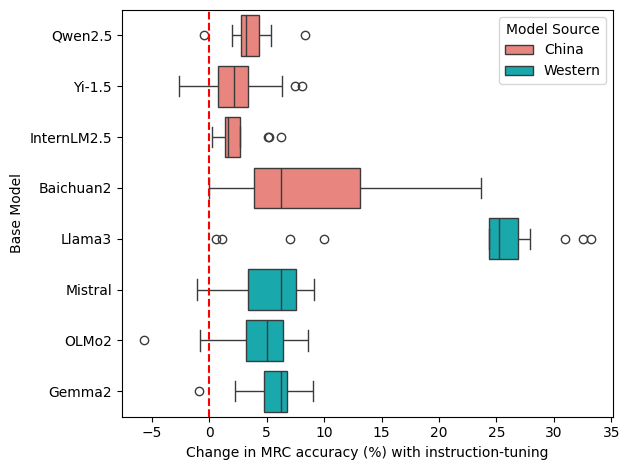

In [31]:
g = sns.boxplot(df1, y='model_family', x='change', palette={"China": "#f8766d", "Western": "#00bfc5"},
order = ["Qwen2.5", "Yi-1.5", "InternLM2.5", "Baichuan2", "Llama3", "Mistral", "OLMo2", "Gemma2"], hue='model_source')
plt.axvline(x=0, ls='--', c='red')
plt.xlabel("Change in MRC accuracy (%) with instruction-tuning")
plt.ylabel("Base Model")
plt.legend(title="Model Source")
plt.tight_layout()
plt.savefig("./figures/bele-instruction-tuned-change-by-model.pdf")

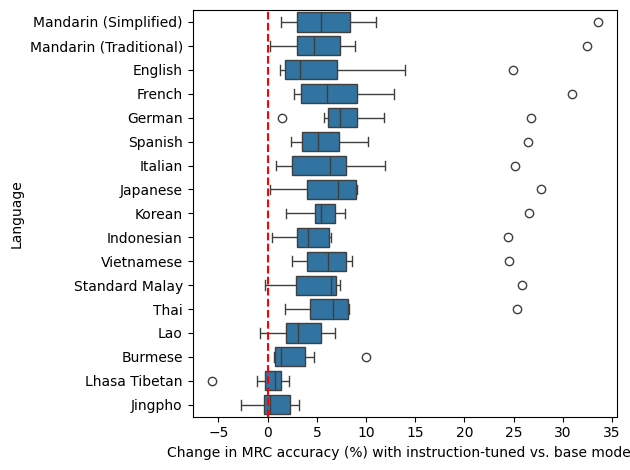

: 

In [ ]:
g = sns.boxplot(df1, y='lang_name', x='change', 
order = ["Mandarin (Simplified)", "Mandarin (Traditional)", "English", "French", "German", "Spanish", "Italian",  "Japanese", "Korean", "Indonesian", "Vietnamese", 
"Standard Malay", "Thai", "Lao", "Burmese", "Lhasa Tibetan", "Jingpho"])
plt.axvline(x=0, ls='--', c='red')
plt.xlabel("Change in MRC accuracy (%) with instruction-tuned vs. base models")
plt.ylabel("Language")
plt.tight_layout()
plt.savefig("./figures/bele-instruction-tuned-change-by-language.pdf")

### chat template vs no chat template

In [37]:
bele = pd.read_csv("bele_output.csv")
bele['model_family'] = bele['model_name'].apply(lambda m: model_family_map[m])
bele['accuracy'] = 100 * bele['accuracy']

df = pd.pivot(bele[bele['instruction_tuned'] == 1],index=['model_name', 'model_name_abrev', 'lang_category', 'lang_name'], columns='chat_template', values='accuracy').reset_index()
df['change'] = df[1]-df[0]

In [38]:
df[df['model_name'].str.contains("Yi")]

chat_template,model_name,model_name_abrev,lang_category,lang_name,0,1,change
119,Yi-1.5-9B-Chat,Yi-1.5-Chat,Chinese Minorities,Jingpho,29.777778,30.555556,0.777778
120,Yi-1.5-9B-Chat,Yi-1.5-Chat,Chinese Minorities,Lhasa Tibetan,28.111111,28.111111,0.000000
121,Yi-1.5-9B-Chat,Yi-1.5-Chat,European,English,90.777778,90.111111,-0.666667
122,Yi-1.5-9B-Chat,Yi-1.5-Chat,European,French,84.888889,84.333333,-0.555556
123,Yi-1.5-9B-Chat,Yi-1.5-Chat,European,German,84.000000,85.777778,1.777778
124,Yi-1.5-9B-Chat,Yi-1.5-Chat,European,Italian,81.888889,82.222222,0.333333
125,Yi-1.5-9B-Chat,Yi-1.5-Chat,European,Spanish,83.555556,85.333333,1.777778
126,Yi-1.5-9B-Chat,Yi-1.5-Chat,Mandarin Chinese,Mandarin (Simplified),89.111111,87.111111,-2.000000
127,Yi-1.5-9B-Chat,Yi-1.5-Chat,Mandarin Chinese,Mandarin (Traditional),85.555556,85.777778,0.222222
128,Yi-1.5-9B-Chat,Yi-1.5-Chat,Northeast Asian,Japanese,76.333333,78.666667,2.333333


In [39]:
df['change'].describe()

count    170.000000
mean       1.450980
std        8.219367
min      -24.000000
25%       -1.638889
50%        0.000000
75%        1.777778
max       27.111111
Name: change, dtype: float64

In [40]:
df.groupby(["model_name"])['change'].describe()


,count,mean,std,min,25%,50%,75%,max
model_name,,,,,,,,
Baichuan2-7B-Chat,17.0,-0.607843,1.311816,-2.777778,-1.333333,-0.888889,0.222222,2.000000
DeepSeek-R1-Distill-Llama-8B,17.0,12.555556,15.999614,-17.555556,-1.111111,22.222222,24.333333,27.111111
DeepSeek-R1-Distill-Qwen-7B,17.0,9.241830,8.332151,-6.444444,6.777778,11.555556,15.444444,18.666667
Meta-Llama-3-8B-Instruct,17.0,-4.032680,10.274832,-24.000000,-10.777778,-2.222222,3.666667,9.111111
Mistral-7B-Instruct-v0.3,17.0,-0.901961,0.748334,-2.222222,-1.444444,-1.111111,-0.444444,0.555556
OLMo-2-1124-7B-Instruct,17.0,-0.843137,1.435366,-3.111111,-2.000000,-0.777778,0.111111,1.777778
Qwen2.5-7B-Instruct,17.0,1.215686,0.702147,0.000000,0.555556,1.222222,1.666667,2.666667
Yi-1.5-9B-Chat,17.0,1.326797,1.651071,-2.000000,0.222222,1.777778,2.777778,3.777778
gemma-2-9b-it,17.0,-0.032680,0.179009,-0.666667,0.000000,0.000000,0.000000,0.111111


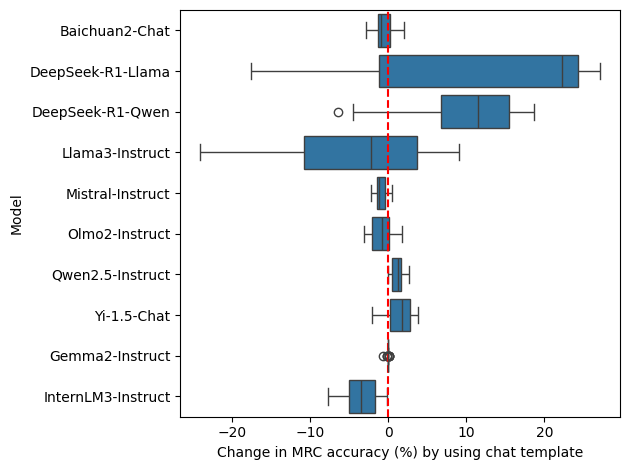

In [42]:
g = sns.boxplot(df, y='model_name_abrev', x='change')
plt.axvline(x=0, ls='--', c='red')
plt.xlabel("Change in MRC accuracy (%) by using chat template")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("./figures/bele-chat-template-change-by-model.pdf")

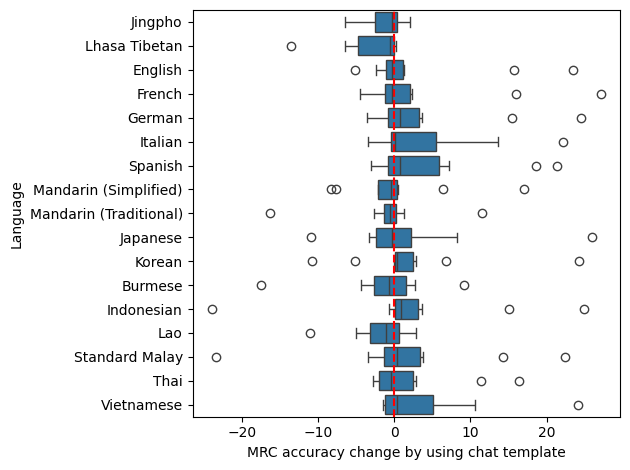

In [43]:
g = sns.boxplot(df, y='lang_name', x='change')
plt.axvline(x=0, ls='--', c='red')
plt.xlabel("MRC accuracy change by using chat template")
plt.ylabel("Language")
plt.tight_layout()
plt.savefig("./figures/bele-chat-template-change-by-language.pdf")